In [18]:
# CELL 0: Setup environment and import custom pipeline modules
# Imports preprocess_image, segment_stamp, and extract_roi from our src modules.
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Ensure project root is accessible
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATASET_ROOT
from src.segmentation import preprocess_image, segment_stamp
from src.localization import (
    extract_roi,
    contour_stamp_score,
)

print("Visualizer Ready.")

Visualizer Ready.


In [19]:
def get_segmentation_stages(image_bgr):
    """
    Recreates segmentation.py steps for visualization only.
    Returns intermediate processing results.
    """
    DISPLAY_WIDTH = 900

    h0, w0 = image_bgr.shape[:2]
    scale = DISPLAY_WIDTH / w0
    new_h = int(h0 * scale)

    resized = cv2.resize(image_bgr, (DISPLAY_WIDTH, new_h))

    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    hue_mask = cv2.inRange(h, 90, 170)
    sat_mask = cv2.inRange(s, 25, 255)
    val_mask = cv2.inRange(v, 30, 255)

    combined_mask = cv2.bitwise_and(hue_mask, sat_mask)
    combined_mask = cv2.bitwise_and(combined_mask, val_mask)

    kernel_open = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (3, 3)
    )

    kernel_close = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (11, 11)
    )

    mask_opened = cv2.morphologyEx(
        combined_mask,
        cv2.MORPH_OPEN,
        kernel_open
    )

    mask_cleaned = cv2.morphologyEx(
        mask_opened,
        cv2.MORPH_CLOSE,
        kernel_close
    )

    return {
        "resized": resized,
        "hue_mask": hue_mask,
        "combined_mask": combined_mask,
        "mask_opened": mask_opened,
        "mask_cleaned": mask_cleaned,
    }

In [20]:
def plot_stage(ax, image, title, cmap=None):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

In [21]:
def get_localization_visualization(image_bgr, mask):
    """
    Recreates localization.py logic for visualization only.
    Returns image with best bounding box drawn.
    """

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []

    for contour in contours:
        result = contour_stamp_score(contour)

        if result is not None:
            candidates.append(result)

    if not candidates:
        return None

    candidates = sorted(
        candidates,
        key=lambda item: item["score"],
        reverse=True
    )

    best = candidates[0]

    vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)

    x = best["x"]
    y = best["y"]
    w = best["w"]
    h = best["h"]

    cv2.rectangle(
        vis,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        3
    )

    return vis

In [22]:
# CELL 1: Define a helper function to plot the stamp extraction pipeline steps
# This function displays: 1) original image, 2) binary HSV mask, 3) masked segmented stamp,
# and 4) final cropped and standardized ROI. Super helpful for debugging pipeline errors!
def plot_extraction_steps(image_path):

    # --------------------------------------------------
    # Original
    # --------------------------------------------------
    original_bgr = preprocess_image(image_path)
    original_rgb = cv2.cvtColor(
        original_bgr,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------
    # Segmentation stages
    # --------------------------------------------------
    stages = get_segmentation_stages(original_bgr)

    mask = stages["mask_cleaned"]

    resized_rgb = cv2.cvtColor(
        stages["resized"],
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------
    # Segmented stamp
    # --------------------------------------------------
    overlay = cv2.bitwise_and(
        resized_rgb,
        resized_rgb,
        mask=mask
    )

    # --------------------------------------------------
    # Localization visualization
    # --------------------------------------------------
    localization_vis = get_localization_visualization(
        original_bgr,
        mask
    )

    # --------------------------------------------------
    # ROI extraction
    # --------------------------------------------------
    roi_bgr = extract_roi(
        original_bgr,
        mask
    )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, axes = plt.subplots(
        2,
        4,
        figsize=(20, 10)
    )

    axes = axes.flatten()

    plot_stage(
        axes[0],
        original_rgb,
        "1. Original"
    )

    plot_stage(
        axes[1],
        stages["hue_mask"],
        "2. Hue Mask",
        cmap="gray"
    )

    plot_stage(
        axes[2],
        stages["combined_mask"],
        "3. Combined HSV Mask",
        cmap="gray"
    )

    plot_stage(
        axes[3],
        stages["mask_opened"],
        "4. Morphological Open",
        cmap="gray"
    )

    plot_stage(
        axes[4],
        stages["mask_cleaned"],
        "5. Morphological Close",
        cmap="gray"
    )

    plot_stage(
        axes[5],
        overlay,
        "6. Segmented Stamp"
    )

    if localization_vis is not None:
        plot_stage(
            axes[6],
            localization_vis,
            "7. Localization"
        )
    else:
        axes[6].text(
            0.5,
            0.5,
            "No Candidate",
            ha="center",
            va="center"
        )
        axes[6].axis("off")

    if roi_bgr is not None:

        roi_rgb = cv2.cvtColor(
            roi_bgr,
            cv2.COLOR_BGR2RGB
        )

        plot_stage(
            axes[7],
            roi_rgb,
            "8. Final ROI"
        )

    else:

        axes[7].text(
            0.5,
            0.5,
            "Extraction Failed",
            ha="center",
            va="center"
        )

        axes[7].set_title(
            "8. Final ROI"
        )

        axes[7].axis("off")

    fig.suptitle(
        f"Extraction Pipeline: {image_path.name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

--- GENUINE STAMP EXTRACTION ---


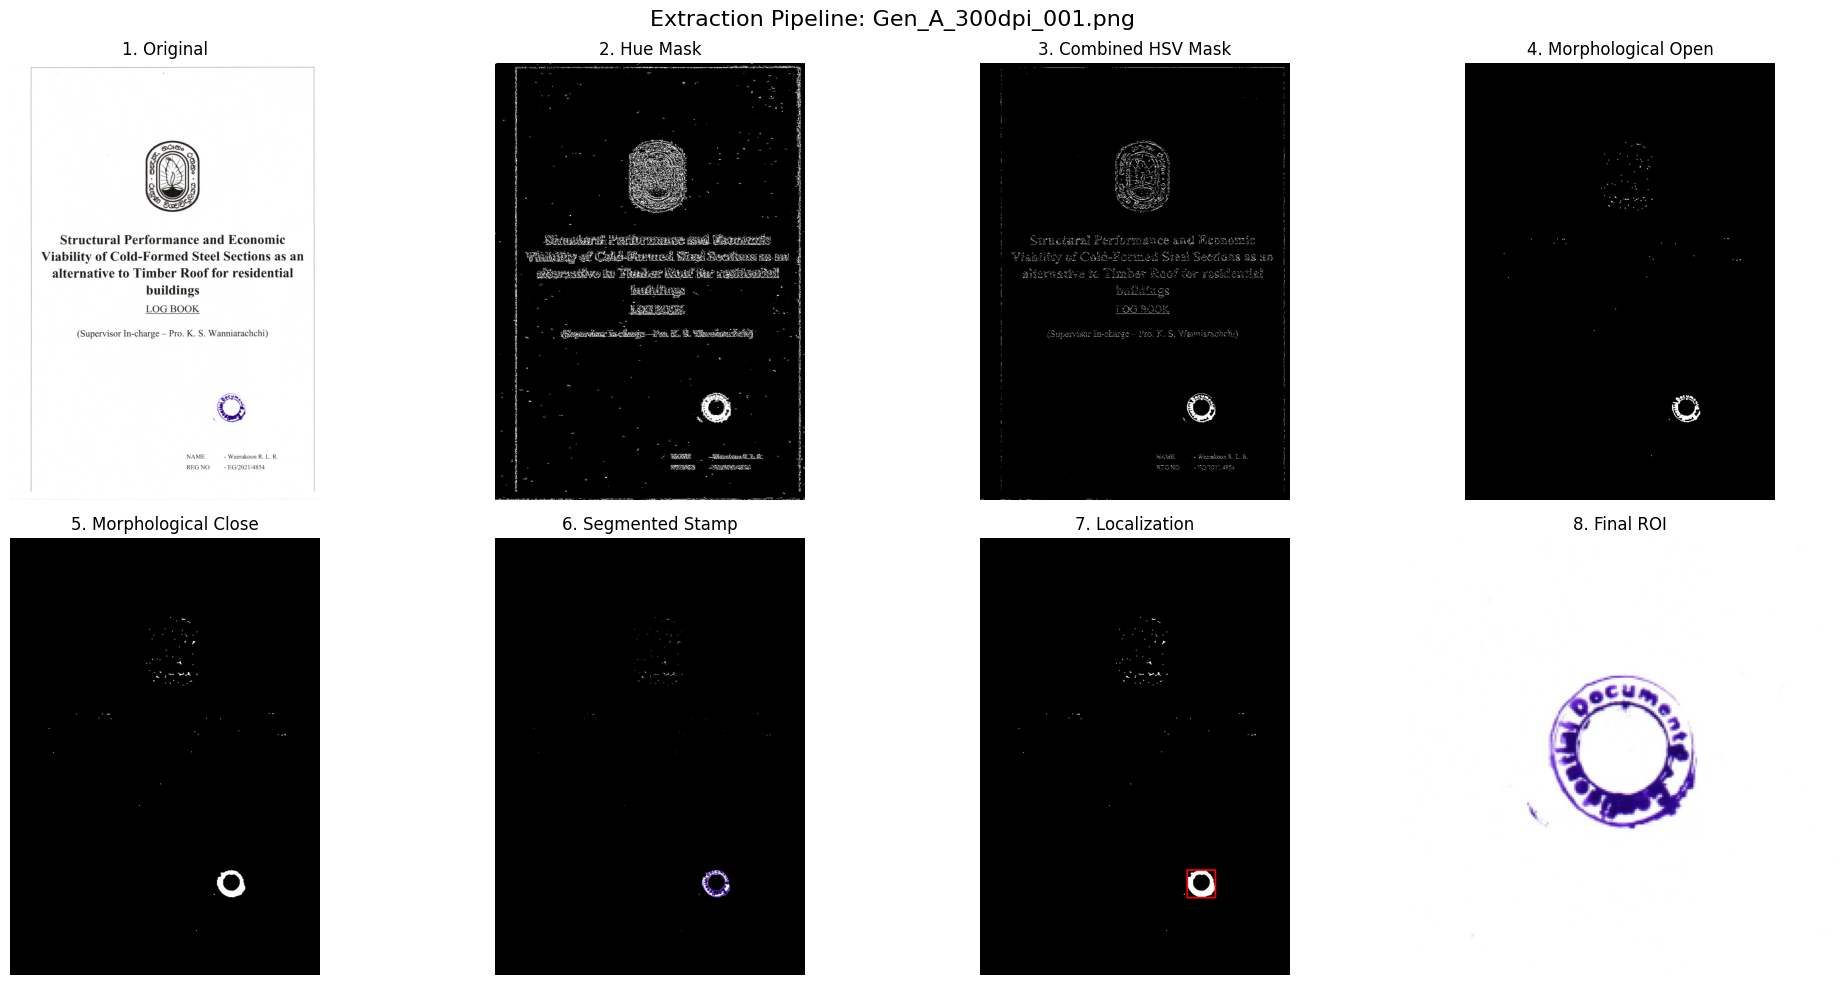

--- FORGED STAMP EXTRACTION ---


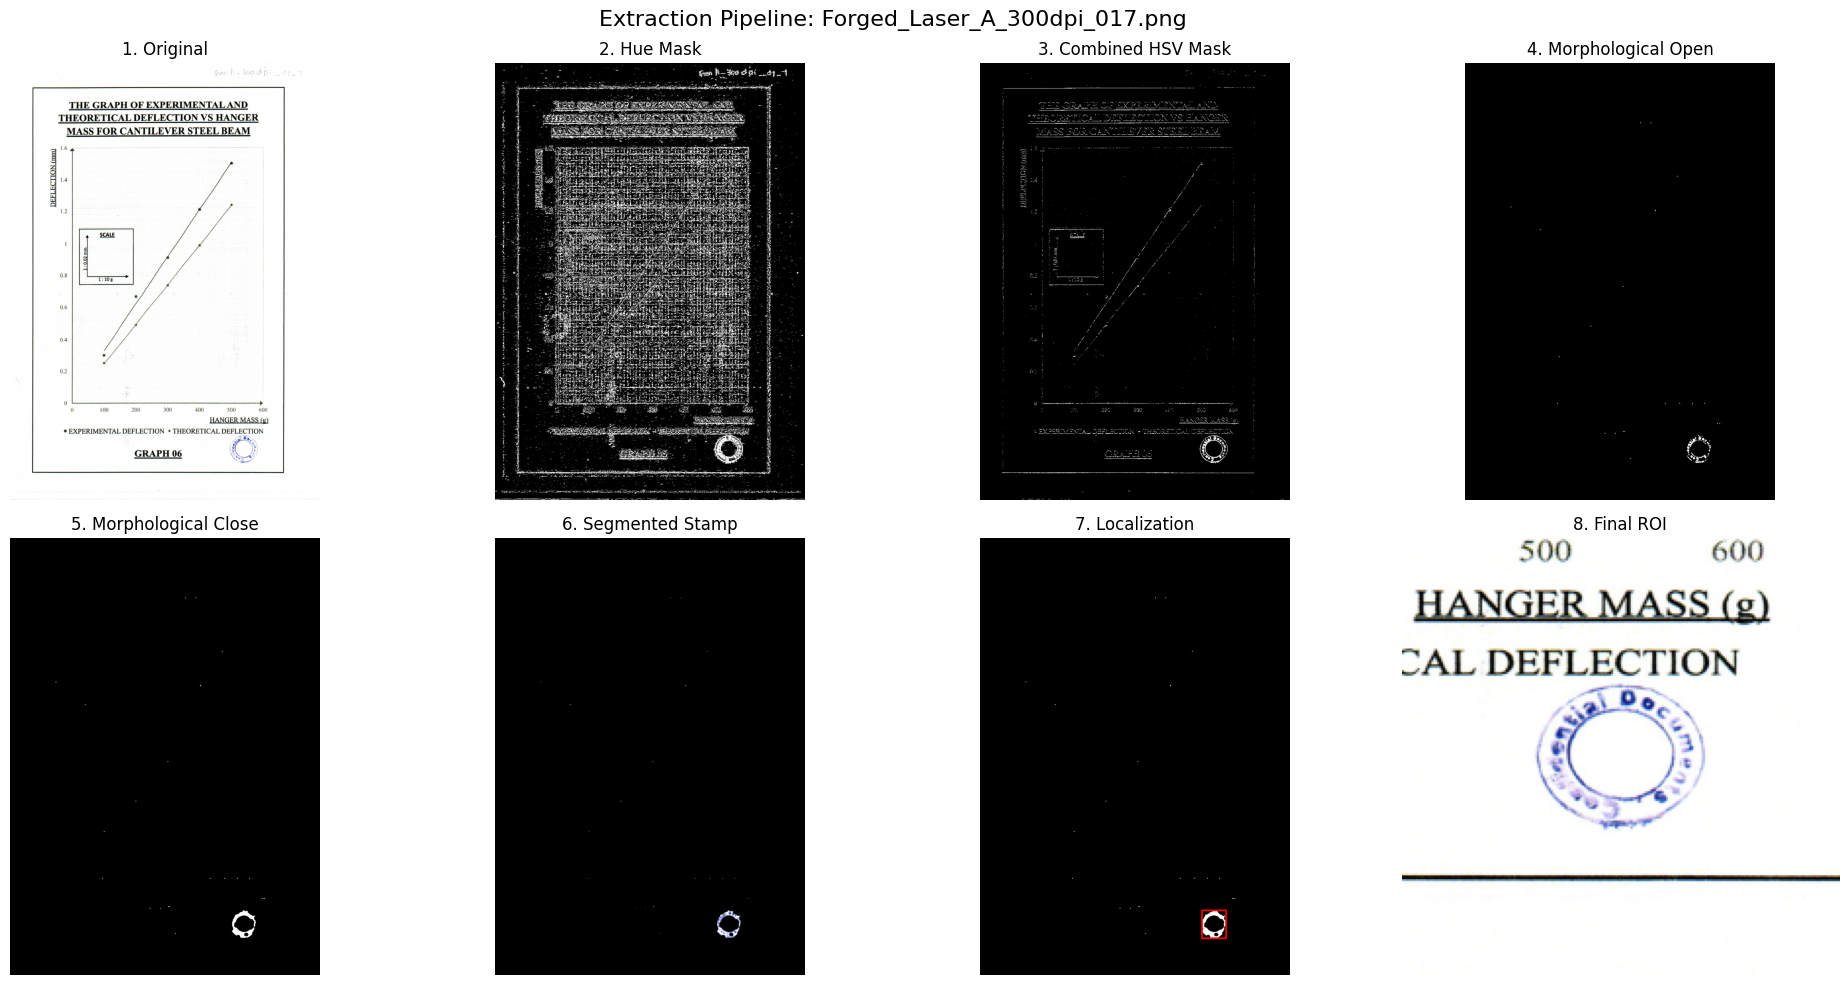

In [23]:
# CELL 2: Demonstrate the extraction pipeline on genuine and forged samples
# We grab the first image from each folder and pass it to plot_extraction_steps
# to show how our computer vision pipeline extracts the stamp.
# Grab one genuine and one forged image to demonstrate
genuine_samples = list((DATASET_ROOT / "class_0_genuine").rglob("*.png"))
forged_samples = list((DATASET_ROOT / "class_1_forged").rglob("*.png"))

print("--- GENUINE STAMP EXTRACTION ---")
if genuine_samples:
    plot_extraction_steps(genuine_samples[0])

print("--- FORGED STAMP EXTRACTION ---")
if forged_samples:
    plot_extraction_steps(forged_samples[0])